# Model Capacity Experiments
This colab shows the code setup we used for the model capacity experiments discussed in section 4.3 of our paper.

#Setup
Code for imports and model setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from itertools import combinations
from sklearn.linear_model import LinearRegression

torch.manual_seed(0)
sns.set_context("paper")
sns.set_style("whitegrid")

In [ ]:
class XORMLP(nn.Module):
    """
    Simple MLP for XOR:
    2 inputs → hidden layer (Tanh) → 1 output (sigmoid)
    """
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(2, width)
        self.act = nn.Tanh()
        self.fc2 = nn.Linear(width, 1)
        self.out_act = nn.Sigmoid()

    def forward(self, x):
        h = self.act(self.fc1(x))
        y = self.out_act(self.fc2(h))
        return y, h

def generate_xor(n=1000):
    """
    Generates XOR dataset:
    """
    X = torch.randint(0, 2, (n, 2)).float()
    y = ((X[:, 0] + X[:, 1]) % 2).unsqueeze(1)
    return X, y

# Experiment setup

Code for analyzing circuits
- Calculates condition number, multiplicity, and effective rank

In [ ]:
# @title
def compute_activation_metrics(model, X):
    """
    Computes condition number of hidden activations.

    Args:
        model: MLP model
        X: Input data (XOR dataset)

    Returns:
        cond : Condition number of hidden activations (ratio of largest to smallest singular value)
    """
    with torch.no_grad():
        _, H = model(X)
    H = H - H.mean(0, keepdim=True)
    H_np = H.detach().cpu().numpy()
    u, s, vh = np.linalg.svd(H_np, full_matrices=False)
    cond = s[0] / s[-1] if len(s) > 1 else np.inf
    return cond

def compute_multiplicity(model, X, y, tol=0.02):
      """
      Computes how many distinct circuits can reproduce the full model output
      within a tolerance.

      Args:
          model: MLP model
          X: Input data
          y: Reference output (not used)
          tol : MSE threshold for considering a circuit valid

      Returns:
          loss: Number of circuits that can approximate
              the full model output within the given tolerance (Valid circuits)
    """
      with torch.no_grad():
          full_pred, H = model(X)
          full_pred = full_pred.squeeze().cpu().numpy()
          H_np = H.detach().cpu().numpy()

      width = H_np.shape[1]
      subsets = []
      for k in range(1, width + 1):
          for combo in combinations(range(width), k):
              h_sub = torch.tensor(H_np[:, combo], dtype=torch.float32)
              out_layer = nn.Linear(len(combo), 1)
              optimizer = optim.LBFGS(out_layer.parameters(), max_iter=50)
              loss_fn = nn.MSELoss()

              def closure():
                  optimizer.zero_grad()
                  pred = torch.sigmoid(out_layer(h_sub))
                  loss = loss_fn(pred.squeeze(), torch.tensor(full_pred))
                  loss.backward()
                  return loss

              optimizer.step(closure)
              with torch.no_grad():
                  pred = torch.sigmoid(out_layer(h_sub)).squeeze().numpy()
                  mse = np.mean((pred - full_pred) ** 2)
              if mse < tol:
                  subsets.append(set(combo))
      unique = []
      for s in subsets:
          if not any(s == u for u in unique):
              unique.append(s)
      return len(unique)


def compute_effective_rank(model, X):
    """
    Compues effective rank of activations

    Args:
        model: MLP model
        X: Input data (XOR dataset)

    Returns:
        eff_rank (float): Effective rank of activations
    """
    with torch.no_grad():
        _, H = model(X)
    H_np = (H - H.mean(0, keepdim=True)).detach().cpu().numpy()
    u, s, _ = np.linalg.svd(H_np, full_matrices=False)
    p = s / s.sum()
    entropy = -(p * np.log(p + 1e-10)).sum()
    eff_rank = np.exp(entropy)
    return eff_rank

#Running Experiment on Model Capacity

In [ ]:
"""
Runs XOR experiments across seeds and hidden sizes while gathering data

Data:
- Hidden Layer Width (Diameter)
- Seed
- Effective Rank
- Condition Number
- Multiplicity (Number of Valid Circuits)

"""
results = []
widths = [3, 4, 5, 6]
seeds = range(10)
records_eff = []
for width in widths:
    for seed in seeds:
        torch.manual_seed(seed)
        X, y = generate_xor()
        model = XORMLP(width)
        opt = optim.Adam(model.parameters(), lr=0.05)
        loss_fn = nn.BCELoss()

        for epoch in range(800):
            opt.zero_grad()
            y_pred, _ = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            opt.step()

        cond = compute_activation_metrics(model, X)
        eff_rank = compute_effective_rank(model, X)
        mult = compute_multiplicity(model, X, y, tol=0.02)

        records_eff.append({
            "width": width,
            "seed": seed,
            "rep_rank": eff_rank,
            "cond": cond,
            "multiplicity": mult
        })
df_eff = pd.DataFrame(records_eff)
df_eff.head()

from google.colab import files
df_eff.to_csv("file.csv", index=False)
files.download("file.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Display Data

Data gathered is shown in the

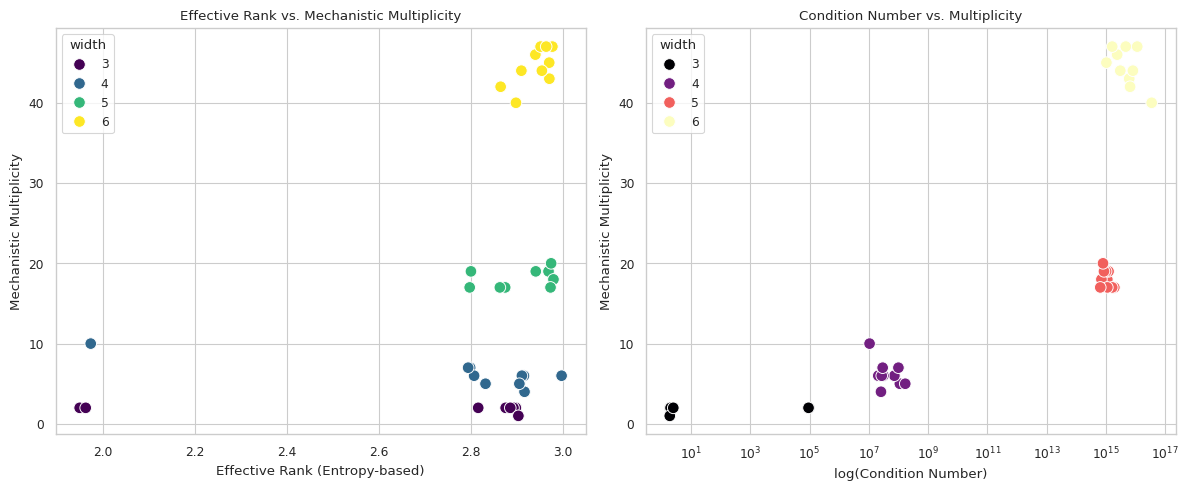

Correlation(effective_rank, multiplicity): 0.311
Correlation(log(cond), multiplicity): 0.800


In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(data=df_eff, x="eff_rank", y="multiplicity", hue="width", palette="viridis", s=70)
plt.title("Effective Rank vs. Mechanistic Multiplicity")
plt.xlabel("Effective Rank (Entropy-based)")
plt.ylabel("Mechanistic Multiplicity")

plt.subplot(1,2,2)
sns.scatterplot(data=df_eff, x="cond", y="multiplicity", hue="width", palette="magma", s=70)
plt.xscale("log")
plt.title("Condition Number vs. Multiplicity")
plt.xlabel("log(Condition Number)")
plt.ylabel("Mechanistic Multiplicity")

plt.tight_layout()
plt.show()

corr_eff = np.corrcoef(df_eff["eff_rank"], df_eff["multiplicity"])[0,1]
corr_cond = np.corrcoef(np.log(df_eff["cond"]), df_eff["multiplicity"])[0,1]
print(f"Correlation(effective_rank, multiplicity): {corr_eff:.3f}")
print(f"Correlation(log(cond), multiplicity): {corr_cond:.3f}")
